# České výstupy pro diplomovou práci: očekávané metriky

Tento notebook pouze lokalizuje a exportuje výsledky vytvořené v
`xG_analysis.ipynb`. Analytické výpočty a přiřazení shluků se zde
neopakují. Díky tomu české popisky ani změna grafického stylu nemohou
změnit výsledek DBSCAN nebo hierarchického shlukování.

Výstupy se ukládají přímo do složky `outputs/`:

- vybrané grafy jako vektorové PDF;
- výsledné tabulky jako CSV.

Před spuštěním tohoto notebooku musí být čistě spuštěn
`xG_analysis.ipynb`.

In [1]:
from pathlib import Path
import json
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    candidate = PROJECT_ROOT.parent
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
    else:
        raise FileNotFoundError("Spusťte notebook z kořenové složky xG.")

CACHE_DIR = PROJECT_ROOT / ".cache" / "thesis_cs"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MPLCONFIG_DIR = PROJECT_ROOT / ".cache" / "matplotlib"

for directory in [OUTPUT_DIR, MPLCONFIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.clustering import plot_cluster_scatter, plot_dendrogram
from src.config import configure_pandas, configure_plots
from src.plotting import (
    plot_identity_scatter,
    plot_rolling_time_series,
)

configure_pandas()
configure_plots()
np.random.seed(42)

REQUIRED_CACHE_FILES = [
    "analysis_metadata.json",
    "league_per_match.csv",
    "season_completeness.csv",
    "rolling_match_top5_ma490.csv",
    "rolling_match_la_liga_ma100.csv",
    "top_offensive.csv",
    "top_defensive.csv",
    "epl_2015.csv",
    "dbscan_pressing_assignments.csv",
    "hierarchical_assignments.csv",
    "hierarchical_summary.csv",
    "hierarchical_linkage.csv",
    "hierarchical_labels.csv",
]
missing_cache_files = [
    name for name in REQUIRED_CACHE_FILES
    if not (CACHE_DIR / name).exists()
]
if missing_cache_files:
    raise FileNotFoundError(
        "Nejprve spusťte xG_analysis.ipynb. Chybí: "
        + ", ".join(missing_cache_files)
    )

metadata = json.loads(
    (CACHE_DIR / "analysis_metadata.json").read_text(encoding="utf-8")
)
assert metadata["rolling_continuous_across_seasons"] is True
assert metadata["rolling_complete_seasons_only"] is True
assert metadata["rolling_level"] == "physical_match"
assert metadata["rolling_top5_window"] == 490
assert metadata["rolling_la_liga_window"] == 100
assert metadata["rolling_monthly_aggregation"] is False
assert metadata["dbscan_eps"] == 0.73
assert metadata["dbscan_min_samples"] == 3
assert metadata["hierarchical_n_clusters"] == 4
assert metadata["stable_team_count"] == 59

def load_csv(name: str, parse_dates: list[str] | None = None) -> pd.DataFrame:
    return pd.read_csv(CACHE_DIR / name, parse_dates=parse_dates)

def save_figure(fig, stem: str) -> None:
    fig.savefig(
        OUTPUT_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )

def export_table(frame: pd.DataFrame, stem: str) -> None:
    frame.to_csv(OUTPUT_DIR / f"{stem}.csv", index=False)

## 1. Srovnání lig na tým a zápas

Tabulka porovnává průměrné hodnoty $xG$ a skutečně vstřelených gólů
na jeden tým a zápas. Vedle počtu týmových zápasů uvádí i obvyklý
počet účastníků, protože Bundesliga má 18 týmů a ostatní sledované
soutěže 20.

In [2]:
league_per_match = load_csv("league_per_match.csv")
league_names_cs = {
    "Bundesliga": "Bundesliga",
    "EPL": "Premier League",
    "La Liga": "La Liga",
    "Ligue 1": "Ligue 1",
    "Serie A": "Serie A",
}

def format_team_range(row) -> str:
    lower = int(row["teams_per_season_min"])
    upper = int(row["teams_per_season_max"])
    return str(lower) if lower == upper else f"{lower}--{upper}"

table_leagues_cs = pd.DataFrame(
    {
        "Liga": league_per_match["league"].map(league_names_cs),
        "Počet týmů v sezóně": league_per_match.apply(
            format_team_range,
            axis=1,
        ),
        "Týmové zápasy": league_per_match["team_matches"].astype(int),
        "$xG$ na tým a zápas": league_per_match[
            "avg_xg_per_team_match"
        ].round(3),
        "Góly na tým a zápas": league_per_match[
            "avg_goals_per_team_match"
        ].round(3),
    }
)
export_table(table_leagues_cs, "tabulka_ligy_na_zapas")
display(table_leagues_cs)

,Liga,Počet týmů v sezóně,Týmové zápasy,$xG$ na tým a zápas,Góly na tým a zápas
0,Bundesliga,18,3672,1.43,1.47
1,Serie A,20,4550,1.35,1.38
2,Premier League,20,4560,1.34,1.36
3,La Liga,20,4560,1.33,1.34
4,Ligue 1,20,4358,1.24,1.29


## 2. Úplnost sezóny 2019/20

In [3]:
completeness = load_csv("season_completeness.csv")
incomplete_cs = completeness.loc[
    ~completeness["full_schedule_coverage"].astype(bool)
].copy()
table_completeness_cs = pd.DataFrame(
    {
        "Liga": incomplete_cs["league"].map(league_names_cs),
        "Sezóna": incomplete_cs["season"],
        "Minimum zápasů týmu": incomplete_cs["min_matches"].astype(int),
        "Maximum zápasů týmu": incomplete_cs["max_matches"].astype(int),
        "Pokrytí (%)": (100 * incomplete_cs["coverage"]).round(1),
    }
)
export_table(
    table_completeness_cs,
    "tabulka_neuplna_sezona_2019_20",
)
display(table_completeness_cs)

,Liga,Sezóna,Minimum zápasů týmu,Maximum zápasů týmu,Pokrytí (%)
28,Ligue 1,2019/20,27,28,73.40
29,Serie A,2019/20,37,38,98.70


## 3. Časový vývoj $xG$ a gólů

Každý zápas vstupuje do chronologické řady jednou a jeho hodnota je
průměrem údajů domácího a hostujícího týmu. Společný graf používá okno
490 zápasů, La Liga okno 100 zápasů. Okno se na hranicích sezón
neresetuje a nepoužívá se měsíční agregace.

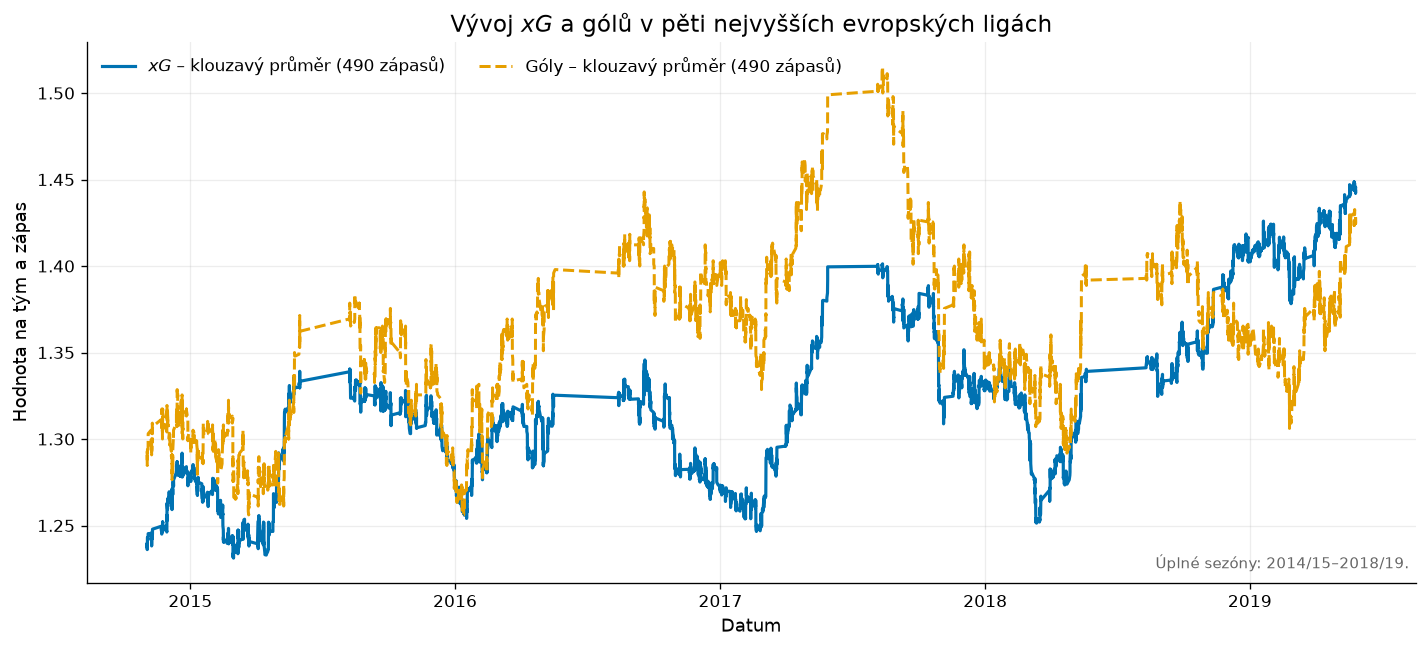

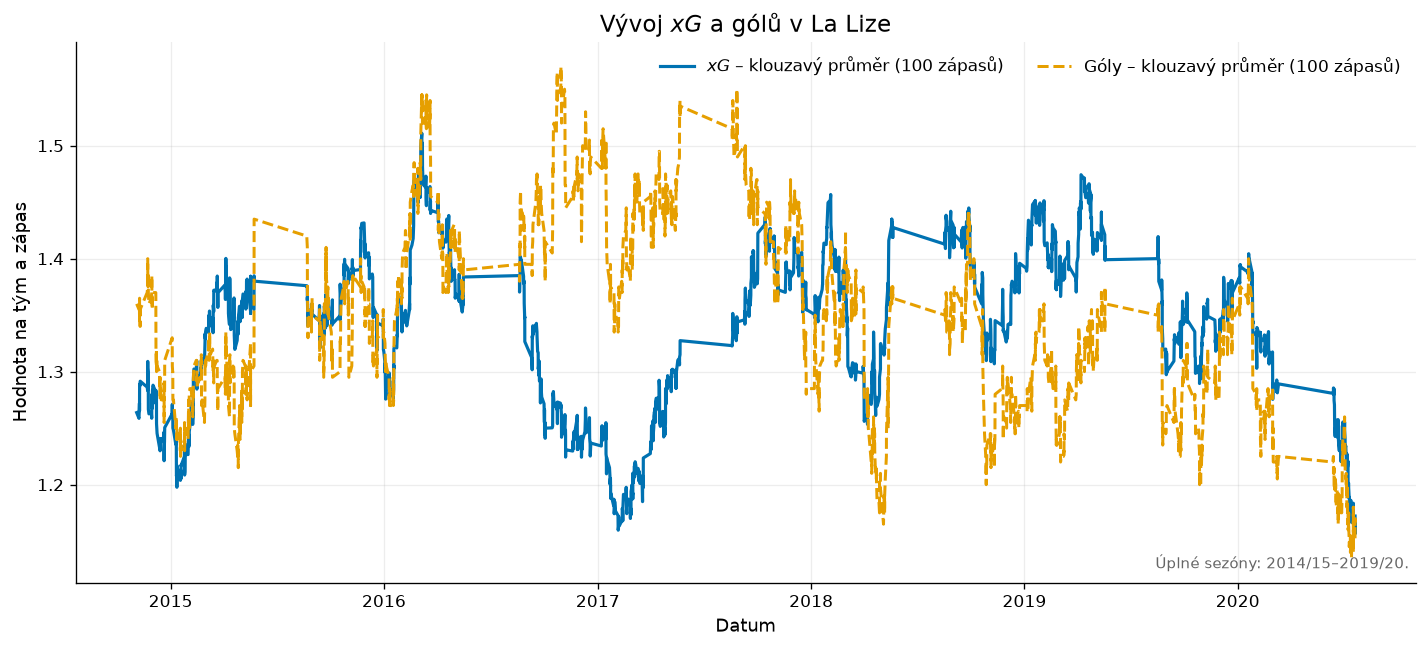

In [4]:
rolling_match_top5_ma490 = load_csv(
    "rolling_match_top5_ma490.csv",
    parse_dates=["date"],
)
rolling_match_la_liga_ma100 = load_csv(
    "rolling_match_la_liga_ma100.csv",
    parse_dates=["date"],
)

fig, ax = plot_rolling_time_series(
    rolling_match_top5_ma490,
    title=(
        "Vývoj $xG$ a gólů v pěti nejvyšších "
        "evropských ligách"
    ),
    xlabel="Datum",
    ylabel="Hodnota na tým a zápas",
    xg_label="$xG$ – klouzavý průměr (490 zápasů)",
    goals_label="Góly – klouzavý průměr (490 zápasů)",
    annotation="Úplné sezóny: 2014/15–2018/19.",
)
save_figure(
    fig,
    "casovy_vyvoj_top5_ma490_zapasy",
)
plt.show()

fig, ax = plot_rolling_time_series(
    rolling_match_la_liga_ma100,
    title="Vývoj $xG$ a gólů v La Lize",
    xlabel="Datum",
    ylabel="Hodnota na tým a zápas",
    xg_label="$xG$ – klouzavý průměr (100 zápasů)",
    goals_label="Góly – klouzavý průměr (100 zápasů)",
    annotation="Úplné sezóny: 2014/15–2019/20.",
)
save_figure(
    fig,
    "casovy_vyvoj_la_liga_ma100_zapasy",
)
plt.show()

## 4. Dlouhodobý výkon nad a pod očekávání

In [5]:
top_offensive = load_csv("top_offensive.csv")
top_defensive = load_csv("top_defensive.csv")

table_offensive_cs = pd.DataFrame(
    {
        "Pořadí": np.arange(1, len(top_offensive) + 1),
        "Liga": top_offensive["league"].map(league_names_cs),
        "Tým": top_offensive["team"],
        "$xG$": top_offensive["xg"].round(2),
        "Góly": top_offensive["goals_scored"].astype(int),
        "$R_{off}$": top_offensive["offensive_ratio"].round(3),
    }
)
table_defensive_cs = pd.DataFrame(
    {
        "Pořadí": np.arange(1, len(top_defensive) + 1),
        "Liga": top_defensive["league"].map(league_names_cs),
        "Tým": top_defensive["team"],
        "$xGA$": top_defensive["xga"].round(2),
        "Obdržené góly": top_defensive["goals_conceded"].astype(int),
        "$R_{def}$": top_defensive["defensive_ratio"].round(3),
    }
)
export_table(table_offensive_cs, "tabulka_utocne_nad_ocekavani")
export_table(table_defensive_cs, "tabulka_obranne_nad_ocekavani")
display(table_offensive_cs)
display(table_defensive_cs)

,Pořadí,Liga,Tým,$xG$,Góly,$R_{off}$
0,1,Serie A,Juventus,388.33,456,1.17
1,2,Bundesliga,Werder Bremen,261.40,298,1.14
2,3,Premier League,Tottenham,365.55,415,1.14
3,4,Ligue 1,Lyon,371.22,418,1.13
4,5,La Liga,Real Sociedad,282.27,315,1.12


,Pořadí,Liga,Tým,$xGA$,Obdržené góly,$R_{def}$
0,1,La Liga,Atletico Madrid,196.64,152,0.77
1,2,La Liga,Barcelona,218.16,190,0.87
2,3,Premier League,Tottenham,267.04,236,0.88
3,4,Premier League,Manchester United,245.02,219,0.89
4,5,Ligue 1,Nice,284.92,255,0.90


## 5. Případová studie Leicester City

Případová studie porovnává skutečné a očekávané body, vstřelené góly
a obdržené góly týmů Premier League v sezóně 2015/16. Leicester je ve
všech třech grafech zvýrazněn. Následující DBSCAN graf porovnává
presinkové profily týmů pomocí ukazatelů PPDA a OPPDA.

In [6]:
epl_2015 = load_csv("epl_2015.csv")

table_leicester_cs = pd.DataFrame(
    {
        "Pořadí": epl_2015["position"].astype(int),
        "Tým": epl_2015["team"],
        "Body": epl_2015["pts"].astype(int),
        "$xPts$": epl_2015["xpts"].round(2),
        "$P-xPts$": epl_2015["points_minus_xpts"].round(2),
        "Góly": epl_2015["scored"].astype(int),
        "$xG$": epl_2015["xg"].round(2),
        "Obdržené": epl_2015["missed"].astype(int),
        "$xGA$": epl_2015["xga"].round(2),
    }
)
export_table(table_leicester_cs, "tabulka_epl_2015_16")
display(table_leicester_cs.head())

,Pořadí,Tým,Body,$xPts$,$P-xPts$,Góly,$xG$,Obdržené,$xGA$
0,1,Leicester,81,68.94,12.06,68,68.42,36,45.02
1,2,Arsenal,71,77.01,-6.01,65,73.53,36,33.86
2,3,Tottenham,70,69.41,0.59,69,63.42,35,37.08
3,4,Manchester United,66,56.44,9.56,49,45.42,35,39.66
4,5,Manchester City,66,70.14,-4.14,71,66.20,41,37.47


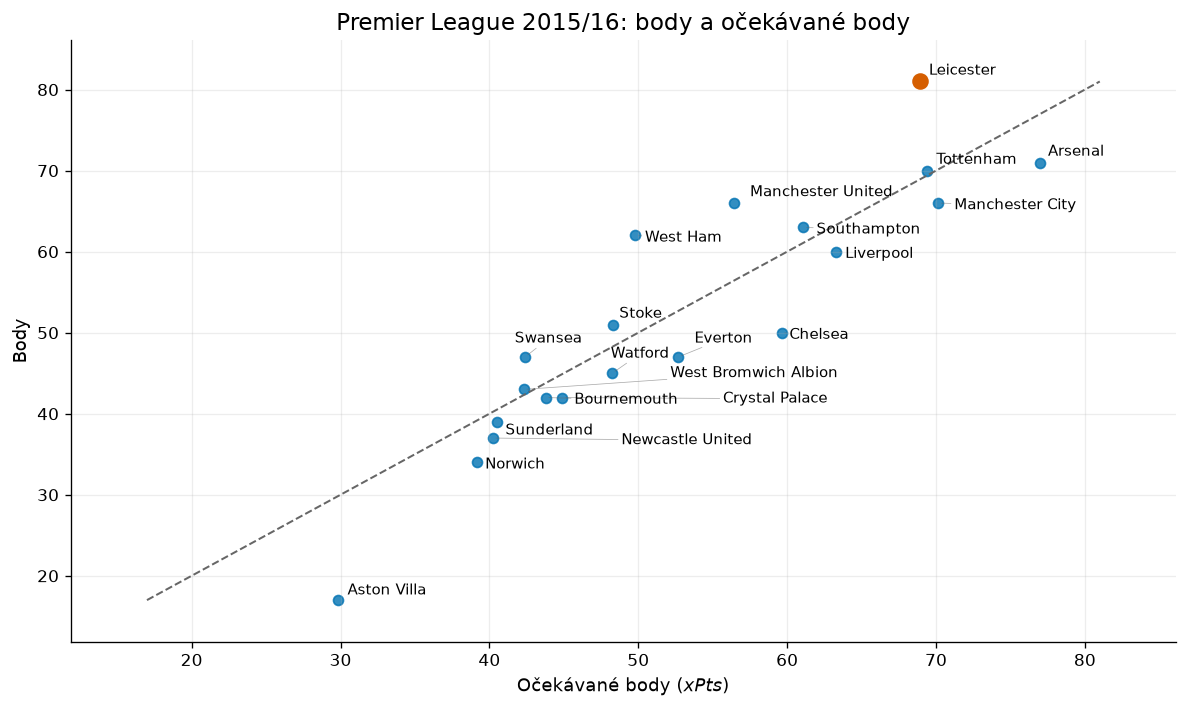

In [7]:
fig, ax = plot_identity_scatter(
    epl_2015,
    x="xpts",
    y="pts",
    highlight=["Leicester"],
    title="Premier League 2015/16: body a očekávané body",
    xlabel="Očekávané body ($xPts$)",
    ylabel="Body",
)
save_figure(fig, "leicester_body_xpts")
plt.show()

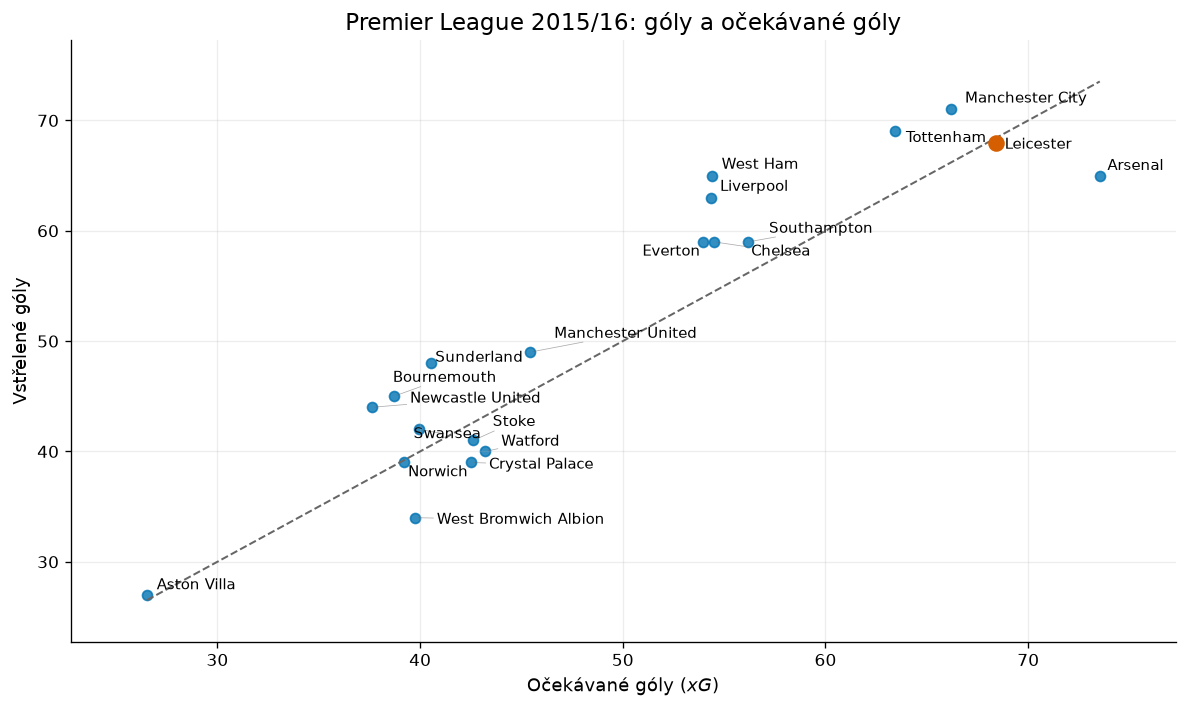

In [8]:
fig, ax = plot_identity_scatter(
    epl_2015,
    x="xg",
    y="scored",
    highlight=["Leicester"],
    title="Premier League 2015/16: góly a očekávané góly",
    xlabel="Očekávané góly ($xG$)",
    ylabel="Vstřelené góly",
)
save_figure(fig, "leicester_goly_xg")
plt.show()

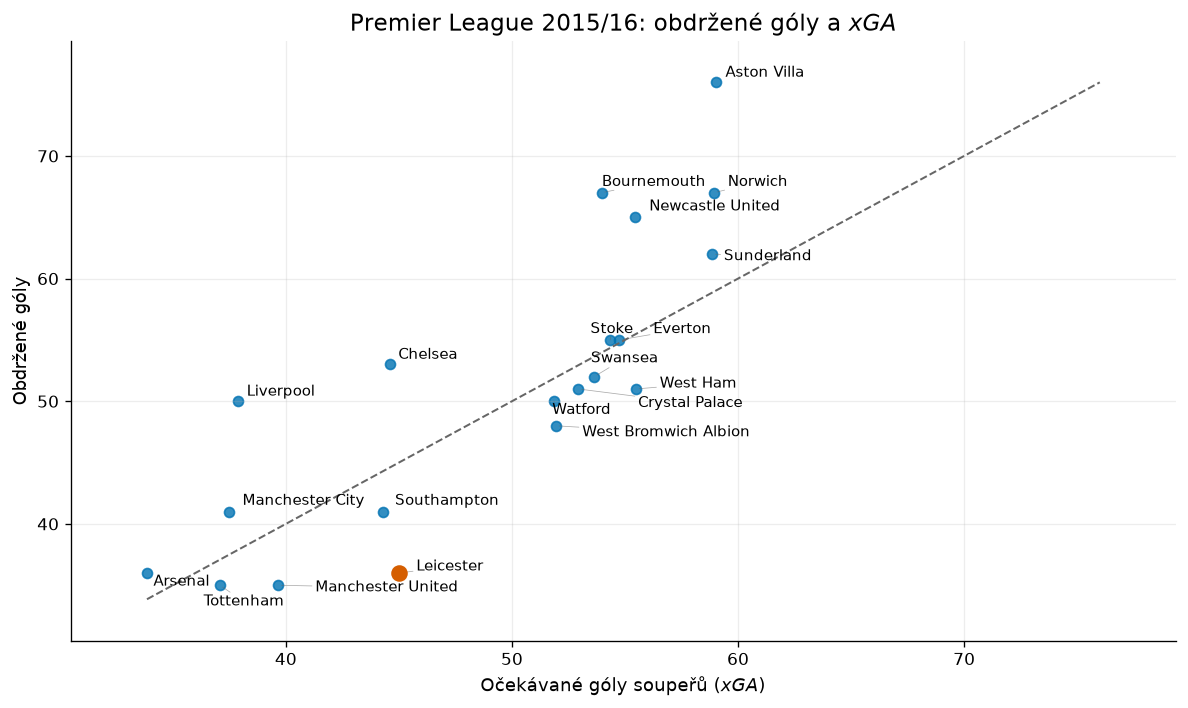

In [9]:
fig, ax = plot_identity_scatter(
    epl_2015,
    x="xga",
    y="missed",
    highlight=["Leicester"],
    title="Premier League 2015/16: obdržené góly a $xGA$",
    xlabel="Očekávané góly soupeřů ($xGA$)",
    ylabel="Obdržené góly",
)
save_figure(fig, "leicester_obdrzene_goly_xga")
plt.show()

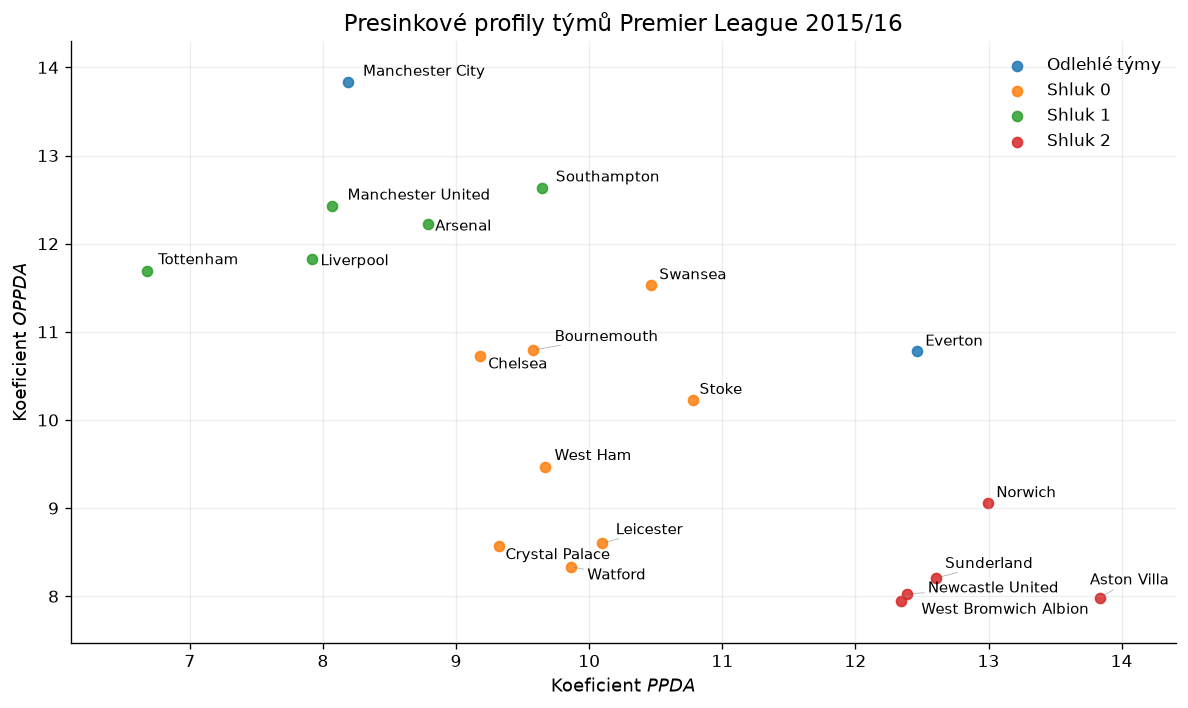

,Shluk,Tým
1,Odlehlý tým,Everton
0,Odlehlý tým,Manchester City
9,0,Bournemouth
5,0,Chelsea
8,0,Crystal Palace
2,0,Leicester
4,0,Stoke
6,0,Swansea
7,0,Watford
3,0,West Ham


In [10]:
dbscan_pressing = load_csv("dbscan_pressing_assignments.csv")
dbscan_pressing["dbscan_cluster"] = (
    dbscan_pressing["dbscan_cluster"].astype(int)
)

expected_pressing_members = {
    -1: ["Everton", "Manchester City"],
    0: [
        "Bournemouth", "Chelsea", "Crystal Palace", "Leicester",
        "Stoke", "Swansea", "Watford", "West Ham",
    ],
    1: [
        "Arsenal", "Liverpool", "Manchester United",
        "Southampton", "Tottenham",
    ],
    2: [
        "Aston Villa", "Newcastle United", "Norwich",
        "Sunderland", "West Bromwich Albion",
    ],
}
observed_pressing_members = {
    int(cluster): sorted(group["team"].tolist())
    for cluster, group in dbscan_pressing.groupby("dbscan_cluster")
}
assert observed_pressing_members == expected_pressing_members

fig, ax = plot_cluster_scatter(
    dbscan_pressing,
    x="ppda_coef",
    y="oppda_coef",
    cluster_col="dbscan_cluster",
    label_col="team",
    title="Presinkové profily týmů Premier League 2015/16",
    cluster_names={
        -1: "Odlehlé týmy",
        0: "Shluk 0",
        1: "Shluk 1",
        2: "Shluk 2",
    },
)
ax.set_xlabel("Koeficient $PPDA$")
ax.set_ylabel("Koeficient $OPPDA$")
save_figure(fig, "leicester_dbscan_pressing")
plt.show()

table_dbscan_cs = (
    dbscan_pressing[["dbscan_cluster", "team"]]
    .rename(columns={"dbscan_cluster": "Shluk", "team": "Tým"})
    .sort_values(["Shluk", "Tým"])
)
table_dbscan_cs["Shluk"] = table_dbscan_cs["Shluk"].replace(
    {-1: "Odlehlý tým"}
)
export_table(table_dbscan_cs, "tabulka_dbscan_pressing")
display(table_dbscan_cs)

## 6. Shluková analýza týmových profilů

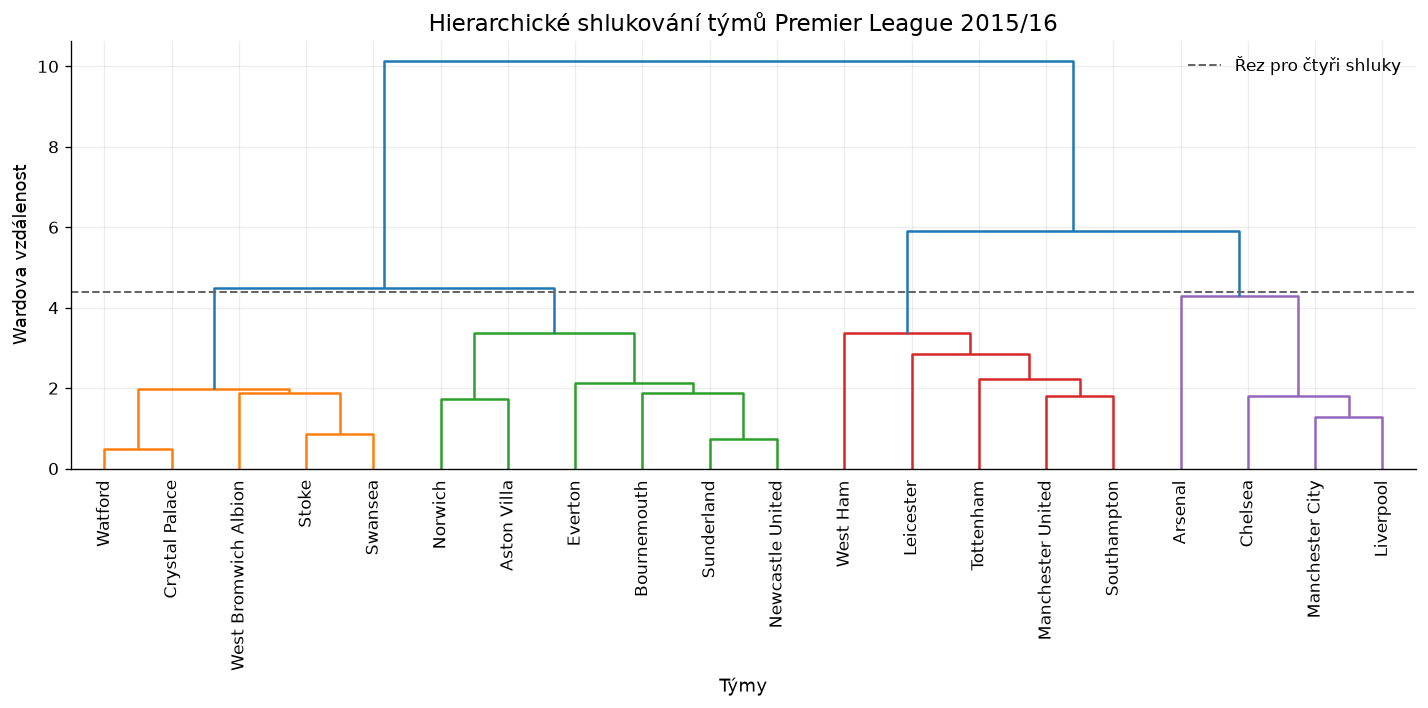

In [11]:
hierarchical_teams = load_csv("hierarchical_assignments.csv")
hierarchical_summary = load_csv("hierarchical_summary.csv")
linkage_matrix = load_csv("hierarchical_linkage.csv").to_numpy()
hierarchical_labels = load_csv("hierarchical_labels.csv")

expected_hierarchical_members = {
    0: ["Arsenal", "Chelsea", "Liverpool", "Manchester City"],
    1: [
        "Aston Villa", "Bournemouth", "Everton",
        "Newcastle United", "Norwich", "Sunderland",
    ],
    2: [
        "Leicester", "Manchester United", "Southampton",
        "Tottenham", "West Ham",
    ],
    3: [
        "Crystal Palace", "Stoke", "Swansea", "Watford",
        "West Bromwich Albion",
    ],
}
observed_hierarchical_members = {
    int(cluster): sorted(group["team"].tolist())
    for cluster, group in hierarchical_teams.groupby("hier_cluster")
}
assert observed_hierarchical_members == expected_hierarchical_members

fig, ax, cut_height = plot_dendrogram(
    linkage_matrix,
    labels=hierarchical_labels["team"].tolist(),
    title="Hierarchické shlukování týmů Premier League 2015/16",
    n_clusters=4,
    xlabel="Týmy",
    ylabel="Wardova vzdálenost",
    cut_label="Řez pro čtyři shluky",
)
save_figure(fig, "hierarchicke_shlukovani_epl_2015")
plt.show()

In [12]:
table_hierarchical_members_cs = (
    hierarchical_teams[["hier_cluster", "team"]]
    .rename(columns={"hier_cluster": "Shluk", "team": "Tým"})
    .sort_values(["Shluk", "Tým"])
)
table_hierarchical_summary_cs = (
    hierarchical_summary[
        [
            "hier_cluster", "n_observations", "xg", "xga",
            "goals_minus_xg", "points_minus_xpts",
            "ppda_coef", "deep",
        ]
    ]
    .rename(
        columns={
            "hier_cluster": "Shluk",
            "n_observations": "Počet týmů",
            "xg": "$xG$",
            "xga": "$xGA$",
            "goals_minus_xg": "$G-xG$",
            "points_minus_xpts": "$P-xPts$",
            "ppda_coef": "$PPDA$",
            "deep": "Deep",
        }
    )
    .round(2)
)

export_table(
    table_hierarchical_members_cs,
    "tabulka_hierarchicke_shluky",
)
export_table(
    table_hierarchical_summary_cs,
    "tabulka_hierarchicke_profily",
)
display(table_hierarchical_members_cs)
display(table_hierarchical_summary_cs)

,Shluk,Tým
0,0,Arsenal
3,0,Chelsea
2,0,Liverpool
1,0,Manchester City
9,1,Aston Villa
5,1,Bournemouth
4,1,Everton
7,1,Newcastle United
8,1,Norwich
6,1,Sunderland


,Shluk,Počet týmů,$xG$,$xGA$,$G-xG$,$P-xPts$,$PPDA$,Deep
0,0,4,62.14,38.46,2.36,-5.76,8.52,393.25
1,1,6,39.42,56.82,4.25,-5.03,12.31,185.83
2,2,5,57.57,44.31,4.43,7.26,8.83,246.40
3,3,5,41.61,52.94,-2.41,0.37,10.55,177.80


## 7. Kontrola exportů

Závěrečná tabulka ověřuje, že každý vybraný graf existuje jako PDF a
každá výsledná tabulka jako CSV.

In [13]:
expected_figure_stems = {
    "casovy_vyvoj_top5_ma490_zapasy",
    "casovy_vyvoj_la_liga_ma100_zapasy",
    "leicester_body_xpts",
    "leicester_goly_xg",
    "leicester_obdrzene_goly_xga",
    "leicester_dbscan_pressing",
    "hierarchicke_shlukovani_epl_2015",
}
expected_table_stems = {
    "tabulka_ligy_na_zapas",
    "tabulka_neuplna_sezona_2019_20",
    "tabulka_utocne_nad_ocekavani",
    "tabulka_obranne_nad_ocekavani",
    "tabulka_epl_2015_16",
    "tabulka_dbscan_pressing",
    "tabulka_hierarchicke_shluky",
    "tabulka_hierarchicke_profily",
}
expected_files = {
    *(f"{stem}.pdf" for stem in expected_figure_stems),
    *(f"{stem}.csv" for stem in expected_table_stems),
}
exported_files = {
    path.relative_to(OUTPUT_DIR).as_posix()
    for path in OUTPUT_DIR.rglob("*")
    if path.is_file() and path.name != "README.md"
}
assert exported_files == expected_files
assert len(exported_files) == 15

export_check = pd.DataFrame({"soubor": sorted(exported_files)})
display(export_check)
print(f"Hotovo: {len(exported_files)} souborů v {OUTPUT_DIR}")

,soubor
0,casovy_vyvoj_la_liga_ma100_zapasy.pdf
1,casovy_vyvoj_top5_ma490_zapasy.pdf
2,hierarchicke_shlukovani_epl_2015.pdf
3,leicester_body_xpts.pdf
4,leicester_dbscan_pressing.pdf
5,leicester_goly_xg.pdf
6,leicester_obdrzene_goly_xga.pdf
7,tabulka_dbscan_pressing.csv
8,tabulka_epl_2015_16.csv
9,tabulka_hierarchicke_profily.csv


Hotovo: 15 souborů v C:\Users\cerve\Desktop\DP\xG\outputs
